In [1]:
%matplotlib inline
import librosa
import soundfile

from IPython import display
from matplotlib import pyplot as plt

### 1. 静音消除（trim:前后）
使用函数：`librosa.effects.trim`:

常用参数：
- `y`: 音频数据`np.ndarray`
- `top_db`： 帧能量，默认`60`
- `ref`: 参考值
- `frame_length`: 帧长度，默认是`2048`
- `hop_length`: 默认是`512`
- `aggregate`:

返回值：
- `y_trimmed`: 截取掉的数据
- `index`: 截取的位置信息，从哪开始到哪结束

**先读取音频数据**

In [2]:
filepath = "../../../data/audio/test/002.wav"
data, sample_rate = librosa.load(filepath, sr=None, mono=False)
data.shape, sample_rate

((176619,), 16000)

**静音消除**

In [3]:
y_trimmed, index = librosa.effects.trim(data, top_db=9)

In [4]:
y_trimmed.shape, index

((23552,), array([ 1024, 24576]))

**波形展示**

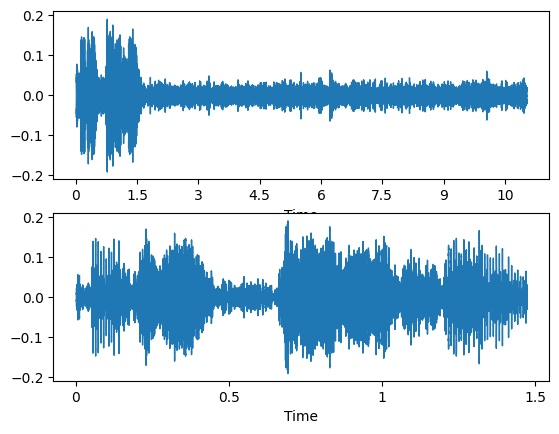

In [5]:
fig, axs = plt.subplots(nrows=2, ncols=1)
librosa.display.waveshow(data, sr=sample_rate, ax=axs[0])
librosa.display.waveshow(y_trimmed, sr=sample_rate, ax=axs[1])

plt.show()

In [6]:
# 播放截取后的音频：
# display.Audio(y_trimmed, rate=sample_rate)

In [7]:
# librosa.effects.trim?

### 2. 消除静音（split:包含中间）

返回的是分段信息

In [8]:
data.shape, sample_rate

((176619,), 16000)

#### 2.1 获取分段信息

In [9]:
intervals = librosa.effects.split(data, top_db=9)
intervals

array([[ 1024,  8704],
       [11264, 24576]])

#### 2.2 重新混合

利用`split`获取到的区间数据，将音频重新合并(取出区间中的数据合并成一个数组)
```python
librosa.effects.remix(y, intervals, * align_zeros=True
```

In [10]:
y_remix = librosa.effects.remix(data, intervals=intervals)
y_remix.shape

(21048,)

In [11]:
# display.Audio(y_remix, rate=sample_rate)

#### 2.3 图形展示

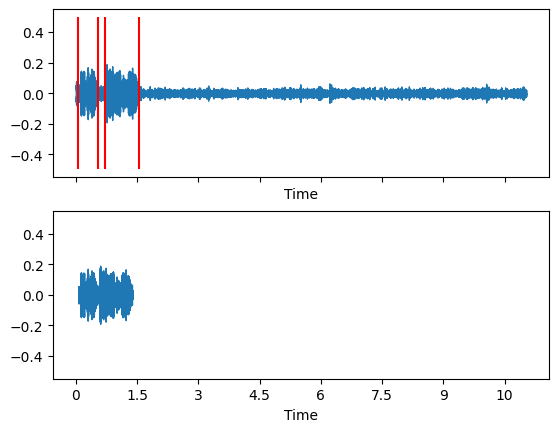

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, sharey=True)
librosa.display.waveshow(data, sr=sample_rate, ax=axs[0])
librosa.display.waveshow(y_remix, sr=sample_rate, ax=axs[1], offset=intervals[0][0]/sample_rate)

for interval in intervals:
    start = interval[0] / sample_rate
    end = interval[1] / sample_rate
    # 画出开始和结束的线
    axs[0].vlines(start, -0.5, 0.5, colors='red')
    axs[0].vlines(end, -0.5, 0.5, colors='red')
plt.show()